
# Un recorrido por la Estadística Espacial

> Los estadísticos son patriotas, ¡luchan por la independencia!

![](images/indep.png)

Este notebook es una **traducción a Python** del archivo `01-Intro.Rmd`. En algunos casos la traducción es directa y, en otros, se usa una implementación equivalente en Python cuando no existe una función idéntica a la disponible en R.



## Introducción

¿Se puede ver todo desde una perspectiva espacial?


In [23]:

import folium

m = folium.Map(location=[-0.1683198, -78.4708585], zoom_start=12, tiles="OpenStreetMap")
folium.Marker(
    location=[-0.1683198, -78.4708585],
    popup="Más allá de la independencia"
).add_to(m)
m



---

**Evolución**

- **iid**: Sean $X_1,\ldots,X_n$ variables aleatorias independientes e idénticamente distribuidas.
- Mediciones repetidas: datos pareados.
- Series de tiempo.
- Correlación $\leftrightarrow$ Autocorrelación $\leftrightarrow$ Autocorrelación Espacial.

**Cressie (2015), publicado por primera vez en 1993**

#### Datos Geoestadísticos

![](images/Geodata.png)

#### Lattice data

![](images/lattice.png)

#### Point patterns

![](images/ppatterns.png)

> Sea $\mathbf{s}\in\mathbb{R}^d$ un dato genérico de posición en un espacio euclideano $d$-dimensional y suponga que el dato observado en $\mathbf{s}$, $\mathbf{Z(s)}$, es una variable aleatoria. Permítase a $\mathbf{Z(s)}$ variar sobre el conjunto índice $D\subset \mathbb{R}^d$ tal que genera el proceso aleatorio (campo aleatorio)
>
> $$
> \{\mathbf{Z(s)}:\mathbf{s}\in D\}
> $$

Usualmente se asume a $D$ fijo, pero podría ser un *conjunto aleatorio*. Es decir, tanto $\mathbf{Z}$ como $D$ pueden variar en cada realización.

- **Datos Geoestadísticos**: $D$ es un subconjunto fijo de $\mathbb{R}^d$ que contiene un rectángulo $d$-dimensional de volumen positivo; $\mathbf{Z(s)}$ es un vector aleatorio en la ubicación $\mathbf{s}\in D$.
- **Datos lattice**: $D$ es una colección fija (regular o irregular) de puntos de $\mathbb{R}^d$; $\mathbf{Z(s)}$ es un vector aleatorio en la ubicación $\mathbf{s}\in D$.
- **Patrones de puntos**: $D$ es un proceso en $\mathbb{R}^d$ o un subconjunto de $\mathbb{R}^d$; $\mathbf{Z(s)}$ es un vector aleatorio en la ubicación $\mathbf{s}\in D$.

#### Ignorando la correlación espacial

- $E(\bar{Z})=\mu$
- $V(\bar{Z})=\frac{\sigma^2_0}{n}$

#### Considerando la correlación espacial

- $E(\bar{Z})=\mu$
- $V(\bar{Z})=\frac{\sigma^2_0}{n}\left(1+\frac{2}{n}\sum_{i<j}^{n}\left(\frac{3}{2}\frac{h}{110}-\frac{1}{2}\frac{h^3}{110^3} \right) \right)$
- $C(h)=\sigma^2_0\left(1-\left(\frac{3}{2}\frac{h}{110}-\frac{1}{2}\frac{h^3}{110^3}\right)\right)$

### Datos espaciales

- Son datos que tienen una referencia espacial: valores de coordenadas y un sistema de referencia (long/lat o UTM).
- Hacer un mapa adecuado que no distorsione los datos subyacentes es desafiante: *How to lie with maps*.
- El análisis de datos espaciales va más allá de lo que se ve en un mapa; trata de responder a la pregunta: *¿cuál es el proceso hipotético que ha generado los datos observados?*
- Las instituciones están cada vez más preocupadas por este tipo de datos, por ejemplo, el Banco Mundial.


![](images/dataWB.png)

---

**En Python**

- El ecosistema espacial en Python se apoya principalmente en `geopandas`, `shapely`, `pyproj`, `rasterio`, `libpysal`, `esda`, `spreg`, `pointpats` y librerías de visualización como `folium` o `contextily`.
- `geopandas` es el análogo más directo a `sf` en muchos flujos de trabajo.



## Modelización

### Geoestadística

La clase de modelos *estables* de correlación está dada por:

$$
\rho(\lVert \mathbf{h} \rVert,\alpha,\beta)=\exp\left\{-\left(\frac{\lVert \mathbf{h}\rVert}{\alpha}\right)^\beta\right\}
$$

donde $\lVert \mathbf{h}\rVert\geq 0$, $\alpha>0$ y $0<\beta\leq 2$.

En Python podemos definir esta función de correlación directamente.


In [24]:

import numpy as np
import matplotlib.pyplot as plt

def cor_fun_stable(lag, r_power, scale):
    lag = np.asarray(lag, dtype=float)
    return np.exp(-np.power(lag / scale, r_power))


Ejemplo:

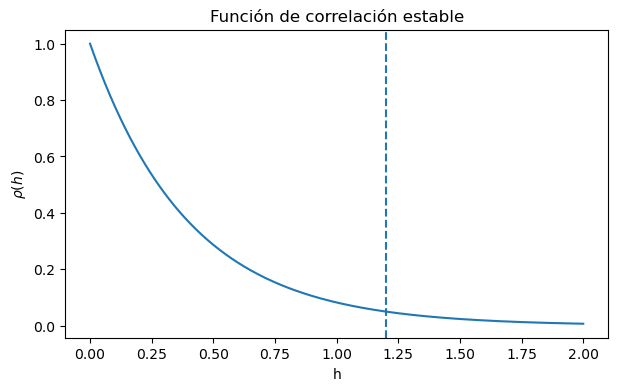

In [25]:

scale = 1.2 / 3
r_power = 1

x = np.linspace(0, 2, 400)
y = cor_fun_stable(x, r_power=r_power, scale=scale)

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.axvline(scale * 3, linestyle="--")
plt.ylabel(r"$\rho(h)$")
plt.xlabel("h")
plt.title("Función de correlación estable")
plt.show()



---

## Aplicaciones

### Point patterns

A continuación se muestra una traducción a Python del ejemplo con emergencias reportadas en ECU 911 en diciembre de 2014 en la zona urbana de Ambato.


In [26]:

from pathlib import Path
import tempfile
import zipfile
import urllib.request

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def read_git_shp(url):
    """Descarga un ZIP con un shapefile y lo lee como GeoDataFrame."""
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = Path(tmpdir) / "shape.zip"
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(tmpdir)

        shp_files = list(Path(tmpdir).rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError("No se encontró ningún archivo .shp dentro del ZIP.")
        return gpd.read_file(shp_files[0])


In [27]:

# Shape de Ambato urbano
shape_url = "https://github.com/vmoprojs/DataLectures/raw/master/SpatialData/shape_Ambato_urbano.zip"
poligonos = read_git_shp(shape_url)

# Datos de emergencias
data_url = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/EmergenciasTransito.txt"
datos = pd.read_csv(data_url, sep=r"\s+")
datos = datos.loc[datos["Month"] == 12].copy()

# Construcción de puntos a partir de longitud y latitud
coord = gpd.GeoDataFrame(
    datos,
    geometry=gpd.points_from_xy(datos["Longitude"], datos["Latitude"]),
    crs="EPSG:4326"
)

# Transformación al CRS del shapefile
coord = coord.to_crs(poligonos.crs)

poligonos.head()


,OBJECTID,NOMBRE,DPA_PARROQ,Shape_Leng,Shape_Area,geometry
0,6,ATOCHA-FICOA,180150,17745.551128,3.725528e+06,"POLYGON ((765052.621 9865045.932, 765052.625 9..."
1,7,LA PENINSULA,180150,15228.595682,4.256663e+06,"POLYGON ((767986.679 9863297.545, 768023.599 9..."
2,8,PISHILATA,180150,10769.525830,4.137434e+06,"POLYGON ((769304.736 9862815.606, 769258.326 9..."
3,9,HUACHI LORETO,180150,11578.372582,3.281191e+06,"POLYGON ((765911.387 9862620.078, 765909.735 9..."
4,10,CELIANO MONJE,180150,12781.578580,5.269846e+06,"POLYGON ((764855.876 9861393.509, 764861.276 9..."


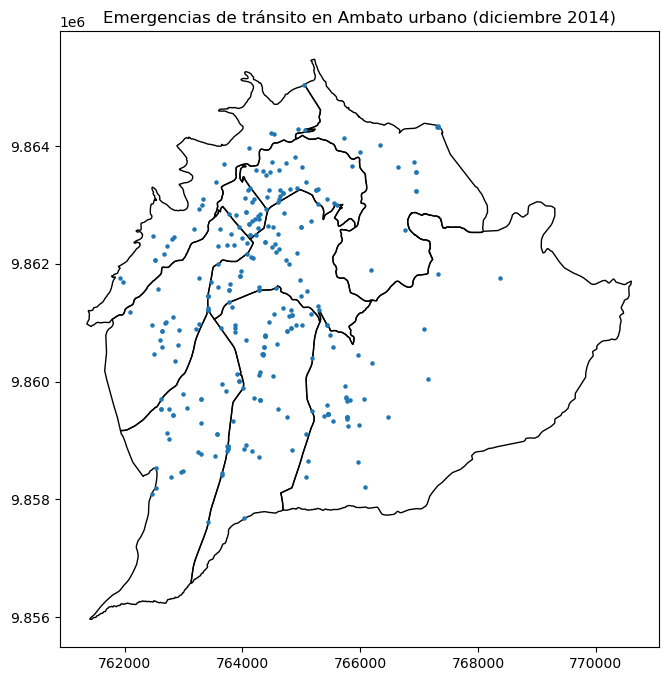

In [28]:

fig, ax = plt.subplots(figsize=(8, 8))
poligonos.plot(ax=ax, facecolor="none", edgecolor="black")
coord.plot(ax=ax, markersize=5)
ax.set_title("Emergencias de tránsito en Ambato urbano (diciembre 2014)")
plt.show()



### Prueba de cuadrantes (*quadrat test*)

En `spatstat` se usa `quadrat.test`. En Python podemos construir una versión equivalente basada en una malla regular y una prueba chi-cuadrado comparando conteos observados vs. esperados bajo CSR (*Complete Spatial Randomness*).


In [29]:

from scipy.stats import chisquare

# Extraer coordenadas proyectadas
xy = np.column_stack([coord.geometry.x.values, coord.geometry.y.values])

# Ventana rectangular
xmin, ymin, xmax, ymax = coord.total_bounds

# Número de cuadrantes
nx, ny = 5, 5
xbreaks = np.linspace(xmin, xmax, nx + 1)
ybreaks = np.linspace(ymin, ymax, ny + 1)

# Conteos observados por celda
obs = np.zeros((ny, nx), dtype=int)
for x0, y0 in xy:
    ix = min(np.searchsorted(xbreaks, x0, side="right") - 1, nx - 1)
    iy = min(np.searchsorted(ybreaks, y0, side="right") - 1, ny - 1)
    obs[iy, ix] += 1

obs_flat = obs.ravel()
expected = np.repeat(len(coord) / (nx * ny), nx * ny)

chi2_stat, pvalue = chisquare(obs_flat, expected)

print(f"Chi-cuadrado: {chi2_stat:.3f}")
print(f"p-valor: {pvalue:.6f}")


Chi-cuadrado: 310.726
p-valor: 0.000000


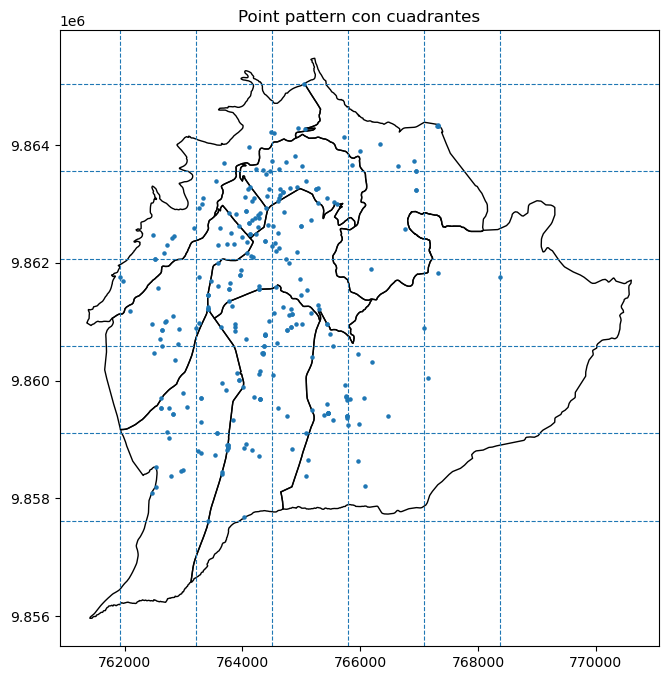

array([[ 7, 17,  3,  2,  0],
       [12, 22, 26,  6,  1],
       [15, 36, 25,  2,  2],
       [ 6, 43, 27,  3,  0],
       [ 0,  6,  9,  7,  4]])

In [30]:

fig, ax = plt.subplots(figsize=(8, 8))
poligonos.plot(ax=ax, facecolor="none", edgecolor="black")
coord.plot(ax=ax, markersize=5)

for xb in xbreaks:
    ax.axvline(xb, linestyle="--", linewidth=0.8)
for yb in ybreaks:
    ax.axhline(yb, linestyle="--", linewidth=0.8)

ax.set_title("Point pattern con cuadrantes")
plt.show()

obs



### Clasificación

El enfoque espacial incluso puede trascender el enfoque *tradicional*.

![](images/fuzzy.png)

---

La distribución espacial de las especies de peces analizada es:

![](images/distfish.png)

---

Algunos resultados:

![](images/clusfish.png)

**Conclusiones**

- Las mayores diferencias entre los cuatro grupos identificados (tácticas de pesca) se determinaron por el arte de pesca, la profundidad y la latitud.
- La aplicación del clasificador *fuzzy* permitió discriminar entre tipos de lances.



### Geoestadística

En el material original se usa `GeoModels` para simular y ajustar un campo aleatorio gaussiano. En Python no existe una traducción 1:1 de `GeoFit`, así que a continuación se presenta una implementación equivalente en espíritu:

1. se simula un campo gaussiano espacial con una matriz de covarianza construida a partir de la correlación exponencial;
2. se muestra un ajuste aproximado con un modelo de proceso gaussiano (`GaussianProcessRegressor`) de `scikit-learn`.


In [31]:

from scipy.spatial.distance import cdist
from numpy.random import default_rng

rng = default_rng(3)

# Coordenadas espaciales
N = 400
x = rng.uniform(0, 1, N)
rng = default_rng(6)
y = rng.uniform(0, 1, N)
coords = np.column_stack([x, y])

# Covariables
X = np.column_stack([np.ones(N), default_rng(10).uniform(0, 1, N)])

# Parámetros
mean = 0.2
mean1 = -0.5
sill = 1.0
nugget = 0.0
scale = 0.2 / 3
r_power = 1.0  # exponencial

# Matriz de distancias y covarianza
D = cdist(coords, coords)
R = cor_fun_stable(D, r_power=r_power, scale=scale)
Sigma = sill * R + nugget * np.eye(N)

# Media espacial
mu = mean + mean1 * X[:, 1]

# Simulación del campo aleatorio gaussiano
z = default_rng(123).multivariate_normal(mean=mu, cov=Sigma)
z[:5]


array([ 0.16877433, -1.10610201, -0.61452103,  0.70862739,  0.08306728])

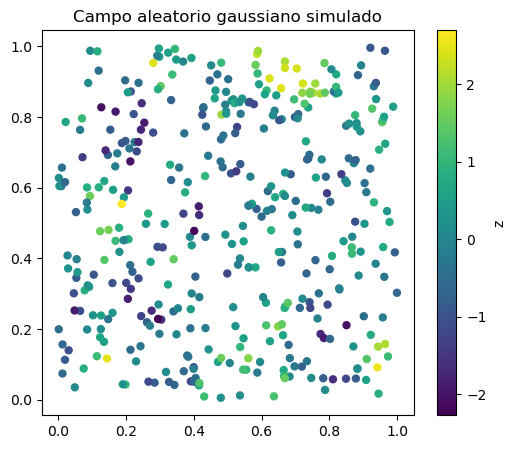

In [32]:

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=z, s=25)
ax.set_title("Campo aleatorio gaussiano simulado")
plt.colorbar(sc, ax=ax, label="z")
plt.show()


In [33]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

# Ajuste aproximado con proceso gaussiano
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))          + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e0))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=123)
gpr.fit(coords, z)

print("Kernel estimado:")
print(gpr.kernel_)
print()
print(f"Log-verosimilitud marginal: {gpr.log_marginal_likelihood(gpr.kernel_.theta):.3f}")


Kernel estimado:
0.803**2 * RBF(length_scale=0.0539) + WhiteKernel(noise_level=0.323)

Log-verosimilitud marginal: -468.997



### Lattice Data

**Distribución espacial del porcentaje de éxito en innovación por provincia**

![](images/mapexitoso.png)

- Se ha encontrado que el componente espacial es significativo en el éxito innovador. Esto implica que existen *spillovers* en la innovación.
- La cercanía geográfica de las empresas es significativa tanto desde un punto de vista descriptivo como desde la modelización.
- El modelo estimado sugiere que la política de innovación debería enfocarse en el componente externo, al mismo tiempo que ciertas dinámicas internas persistentes deberían ser mitigadas.



## Conclusiones

**Hacia la Ciencia de Datos Espaciales**

Métodos:

- Estadística espacio-temporal (geoestadística, patrones de puntos, métodos de estimación).
- Nuevas fuentes de datos espaciales (redes sociales, Google, sensores remotos).
- Geometría estocástica, teselados y procesos de puntos.
- Modelización causal.
- Modelización predictiva.
- Calidad de datos espaciales e incertidumbre.

---

> hay que aprender a juzgar una sociedad por sus ruidos, por su arte y por sus fiestas más que por sus estadísticas.
